In [ ]:
# %%
from matplotlib import pyplot as plt
import os
import glob
import warnings
import argparse

import numpy as np
import pandas as pd
import scanpy as sc
import scipy.io
from scipy.sparse import csr_matrix, issparse
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr, kendalltau, pearsonr

from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.metrics.cluster import normalized_mutual_info_score, homogeneity_score

import torch

from DiverTI.utils import *
from DiverTI.genenet import obtain_genenet
from DiverTI.train import *

warnings.filterwarnings("ignore")

os.environ["R_HOME"] = r"D:\R-4.5.0"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
seed_all(2023)

print("device:", device)
print("scanpy:", sc.__version__)

device: cuda:0
scanpy: 1.9.8


In [ ]:
# %%
DATA_DIR = r"F:\DiverTI\simulated data\stdata\continuous"

dataset_name = "continuous_rep15"

counts_path = os.path.join(DATA_DIR, f"{dataset_name}_counts.mtx")
genes_path  = os.path.join(DATA_DIR, f"{dataset_name}_genes.csv")
cells_path  = os.path.join(DATA_DIR, f"{dataset_name}_cells.csv")
meta_path   = os.path.join(DATA_DIR, f"{dataset_name}_meta.csv")

for p in [counts_path, genes_path, cells_path, meta_path]:
    print(p, os.path.exists(p))

C:\Users\yuanyuan\Documents\SpaTrack_simulations\continuous_rep15_counts.mtx True
C:\Users\yuanyuan\Documents\SpaTrack_simulations\continuous_rep15_genes.csv True
C:\Users\yuanyuan\Documents\SpaTrack_simulations\continuous_rep15_cells.csv True
C:\Users\yuanyuan\Documents\SpaTrack_simulations\continuous_rep15_meta.csv True


In [ ]:
# %%
def load_spatrack_simulation(data_dir, dataset_name):
    counts_path = os.path.join(data_dir, f"{dataset_name}_counts.mtx")
    genes_path  = os.path.join(data_dir, f"{dataset_name}_genes.csv")
    cells_path  = os.path.join(data_dir, f"{dataset_name}_cells.csv")
    meta_path   = os.path.join(data_dir, f"{dataset_name}_meta.csv")

    X = scipy.io.mmread(counts_path).tocsr()   # genes x cells
    genes = pd.read_csv(genes_path)
    cells = pd.read_csv(cells_path)
    meta  = pd.read_csv(meta_path)

    X = X.T.tocsr()

    adata = sc.AnnData(X=X)

    # var_names
    if "gene_id" in genes.columns:
        adata.var_names = genes["gene_id"].astype(str).values
    else:
        adata.var_names = genes.iloc[:, 0].astype(str).values

    # obs_names
    if "cell_id" in cells.columns:
        adata.obs_names = cells["cell_id"].astype(str).values
    else:
        adata.obs_names = cells.iloc[:, 0].astype(str).values

    if "cell_id" in meta.columns:
        meta["cell_id"] = meta["cell_id"].astype(str)
        meta = meta.set_index("cell_id").loc[adata.obs_names].copy()
    else:
        meta.index = adata.obs_names

    adata.obs["cluster"] = meta["cluster"].astype(str).values
    adata.obs["gt_pseudotime"] = pd.to_numeric(meta["pseudotime"], errors="coerce")
    adata.obs["step"] = pd.to_numeric(meta["step"], errors="coerce")
    adata.obs["topology"] = meta["topology"].astype(str).values

    adata.obsm["spatial"] = meta[["spatial_x", "spatial_y"]].values.astype(np.float32)

    if not issparse(adata.X):
        adata.X = csr_matrix(np.asarray(adata.X, dtype=np.float32))
    else:
        adata.X = adata.X.tocsr().astype(np.float32)

    adata.var_names_make_unique()
    return adata

adata = load_spatrack_simulation(DATA_DIR, dataset_name)

print(adata)
print("obs columns:", adata.obs.columns.tolist())
print("obsm keys:", list(adata.obsm.keys()))
print("cluster counts:")
print(adata.obs["cluster"].value_counts())
print("spatial shape:", adata.obsm["spatial"].shape)
print("topology:", adata.obs["topology"].iloc[0])

AnnData object with n_obs × n_vars = 3000 × 3000
    obs: 'cluster', 'gt_pseudotime', 'step', 'topology'
    obsm: 'spatial'
obs columns: ['cluster', 'gt_pseudotime', 'step', 'topology']
obsm keys: ['spatial']
cluster counts:
cluster
1    750
2    750
4    750
3    750
Name: count, dtype: int64
spatial shape: (3000, 2)
topology: continuous


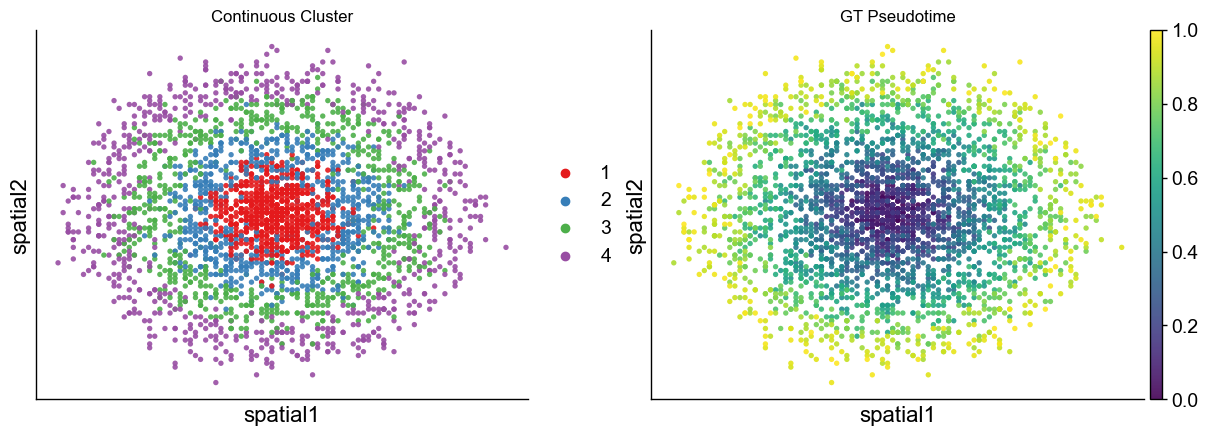

In [ ]:
# %%
import scanpy as sc
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.titlesize'] = 18

sci_palette = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
    "#ffff33", "#a65628", "#f781bf", "#999999", "#1b9e77"   
]

sc.pl.embedding(
    adata,
    basis="spatial",
    color=["cluster", "gt_pseudotime"],
    title=["Continuous Cluster", "GT Pseudotime"],
    ncols=2,
    size=60,
    alpha=0.9,
    legend_fontsize=14,
    cmap="viridis",             
    palette=sci_palette,        
)

In [5]:
# %%
sc.pl.embedding(
    adata,
    basis="spatial",
    color=["cluster", "gt_pseudotime"],
    ncols=2
)

: 

In [6]:
# %%
def estimate_radius(coords, k=6, scale=1.5):
    d = cdist(coords, coords)
    np.fill_diagonal(d, np.inf)
    kth = np.partition(d, k - 1, axis=1)[:, k - 1]
    return float(np.median(kth) * scale)

prefilter_genes(adata, min_cells=3)
adata, adata_raw = svg(adata, svg_method='gft_top', n_top=1000)

rad_cutoff = estimate_radius(adata.obsm["spatial"], k=6, scale=1.5)
print(f"auto rad_cutoff = {rad_cutoff:.4f}")

obtain_spotnet(adata, knn_method='Radius', rad_cutoff=rad_cutoff)
gene_freq_mtx, gene_eigvecs_T, gene_eigvals = f2s_gene(adata, gene_signal=1000, c1=0.05)
obtain_genenet(adata)
spot_freq_mtx, spot_eigvecs_T, spot_eigvals = f2s_spot(adata, spot_signal=1000, middle=3, c2=0.005)
obtain_pre_spotnet(adata, adata_raw)

auto rad_cutoff = 106.0660
gene edges 1080 spots 3000


In [7]:
# %%
res, lamda, emb_spot, _, attention = train_spot(
    adata,
    gene_freq_mtx,
    gene_eigvecs_T,
    spot_freq_mtx,
    spot_eigvecs_T,
    alpha=20,
    device=device,
    epoch_max=200
)

adata.obsm["emb"] = emb_spot
print("emb shape:", adata.obsm["emb"].shape)

spot*signal train


100%|██████████| 200/200 [00:17<00:00, 11.15it/s]

emb shape: (3000, 30)


In [8]:
# %%
sc.pp.neighbors(adata, use_rep='emb')

cluster_num = adata.obs['cluster'].astype(str).nunique()
print("cluster_num =", cluster_num)

adata = mclust_R(adata, used_obsm='emb', num_cluster=cluster_num)
adata.obs['mclust'] = adata.obs['mclust'].astype(str)

adata.obs['domain'] = adata.obs['mclust'].copy()
new_type = refine_label(adata, radius=40, key='domain')
adata.obs['domain'] = pd.Series(new_type, index=adata.obs.index).astype(str)

obs_df = adata.obs[['cluster', 'mclust', 'domain']].dropna().copy()

NMI_score = normalized_mutual_info_score(obs_df['mclust'], obs_df['cluster'], average_method='max')
HS_score  = homogeneity_score(obs_df['mclust'], obs_df['cluster'])
ARI_score = adjusted_rand_score(obs_df['domain'], obs_df['cluster'])
AMI_score = adjusted_mutual_info_score(obs_df['cluster'], obs_df['domain'], average_method='arithmetic')

print('AMI:', AMI_score)
print('ARI:', ARI_score)
print('NMI:', NMI_score)
print('HS :', HS_score)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



cluster_num = 4
fitting ...
  |======================================================================| 100%
AMI: 0.5439024618092047
ARI: 0.47747186548304954
NMI: 0.5171268995035762
HS : 0.5308579726877541


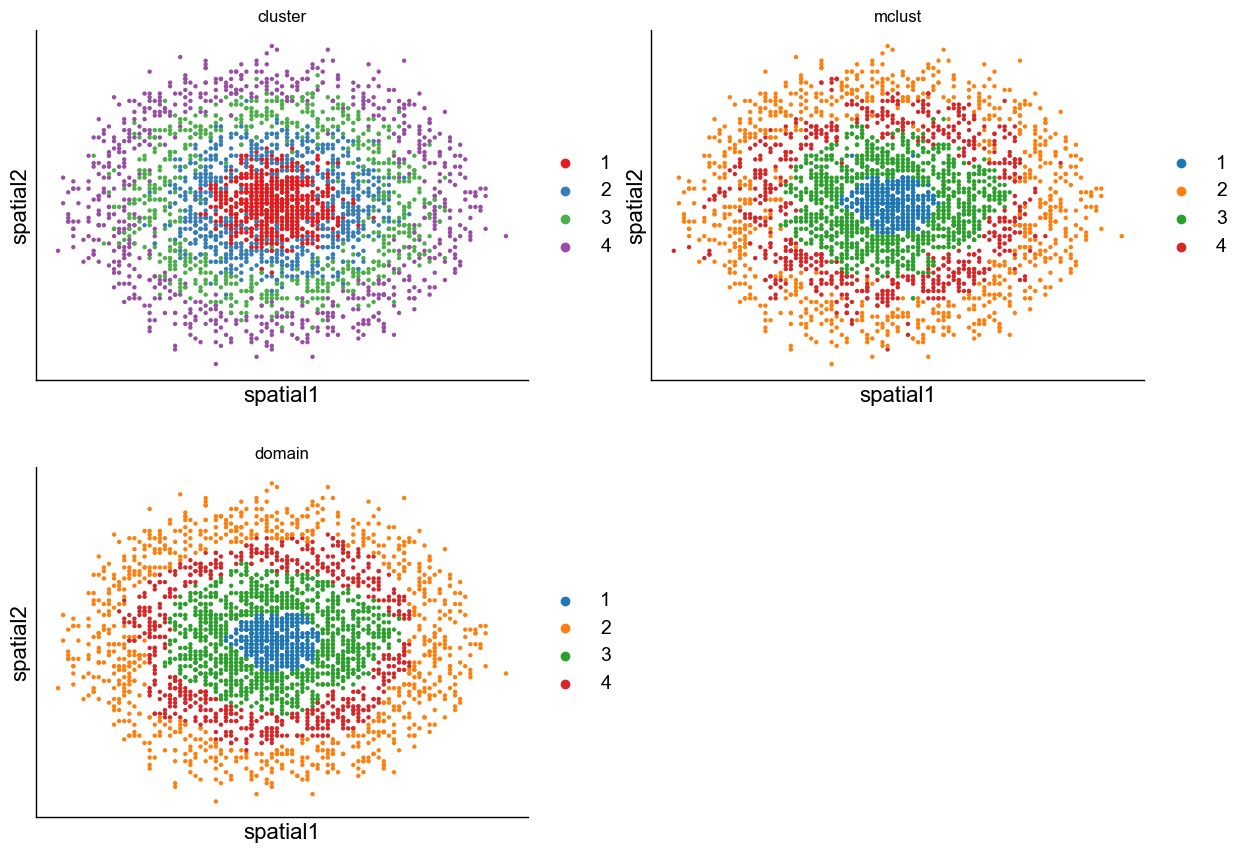

In [9]:
# %%
sc.pl.embedding(
    adata,
    basis='spatial',
    color=['cluster', 'mclust', 'domain'],
    title=['cluster', 'mclust', 'domain'],
    ncols=2
)

In [ ]:
# %%
from infer import InferExperiment

adata.obsm['cascat_embedding'] = adata.obsm['emb'].copy()

adata.obs['cascat_clusters'] = adata.obs['mclust'].astype(str).copy()

tmp = adata.obs[['cluster', 'gt_pseudotime']].dropna().copy()
tmp['cluster'] = tmp['cluster'].astype(str)

root_label = tmp.groupby('cluster')['gt_pseudotime'].median().sort_values().index[0]
print("root_label =", root_label)

parser = argparse.ArgumentParser()
parser.add_argument("--root", type=str, default=str(root_label))
parser.add_argument("--a_k", type=int, default=30)
parser.add_argument("--ncomp", type=int, default=10)
parser.add_argument("--threshold", type=float, default=0.3)
parser.add_argument("--job_dir", type=str, default=fr"./result/trajectory/{dataset_name}")
parser.add_argument("--seed", type=int, default=2023)
parser.add_argument("--data_name", type=str, default=dataset_name)

args_traj = parser.parse_args([])

exp = InferExperiment(args_traj, adata=adata)

print("cascat_clusters dtype:", adata.obs['cascat_clusters'].dtype)
print("cascat_clusters unique:", sorted(adata.obs['cascat_clusters'].unique()))
print(adata.obs['cascat_clusters'].value_counts())

root_label = 1
using keys are cascat_clusters, cascat_embedding, cascat_connectivities, cascat_pseudotime, cascat_di_matrix
group_frac:        2      4      1      3
4  654.0   96.0    0.0    0.0
1    0.0    1.0  449.0  300.0
3  206.0  462.0    0.0   82.0
2    2.0  113.0   23.0  612.0
No start cell id, use truth label in cluster to find start cell
Root is 1, Start cell idx is 5
Finish load Infer params
Finish initialize tree params
cascat_clusters dtype: object
cascat_clusters unique: ['1', '2', '3', '4']
cascat_clusters
3    994
2    862
4    672
1    472
Name: count, dtype: int64


In [11]:
# %%
start_cell_id = adata.obs['gt_pseudotime'].astype(float).idxmin()
adata.uns['start_id'] = start_cell_id

print("start_id:", adata.uns['start_id'])

traj_out = exp.infer()

print("infer() output:", traj_out)
print("cascat_pseudotime in obs:", 'cascat_pseudotime' in adata.obs.columns)

start_id: Cell216
树节点: ['4', '1', '3', '2']
=== 基于DI矩阵构建树结构 ===
计算全局DI矩阵: ./result/trajectory/continuous_rep15/trial2023/global_DI_matrix.csv
加载已存在的DI矩阵
完全图构建完成: 4 节点, 6 边
最小生成树构建完成: 3 边
有向树构建完成: 3 边
=== 树结构二值化 ===
树结构二值化完成
树构建完成: 4 节点, 3 边
开始基于DI的树构建
树节点: ['4', '1', '3', '2']
=== 基于DI矩阵构建树结构 ===
计算全局DI矩阵: ./result/trajectory/continuous_rep15/trial2023/global_DI_matrix.csv
加载已存在的DI矩阵
完全图构建完成: 4 节点, 6 边
最小生成树构建完成: 3 边
有向树构建完成: 3 边
=== 树结构二值化 ===
树结构二值化完成
树构建完成: 4 节点, 3 边
✅ 有向树邻接矩阵生成完成，已存入adata.uns['cascat_directed_tree_conn']
生成的邻接矩阵：
     1    2    3    4
1  0.0  0.0  1.0  0.0
2  0.0  0.0  0.0  0.0
3  0.0  0.0  0.0  1.0
4  0.0  1.0  0.0  0.0
基于DI的树构建完成
Number of inf in pseudotime is 0
No ground truth for evaluation
infer() output: (None, None, None, None)
cascat_pseudotime in obs: True


从DI矩阵构建的连接矩阵:
     1    2    3    4
1  0.0  0.0  1.0  0.0
2  0.0  0.0  0.0  0.0
3  0.0  0.0  0.0  1.0
4  0.0  1.0  0.0  0.0
非零连接数: 3


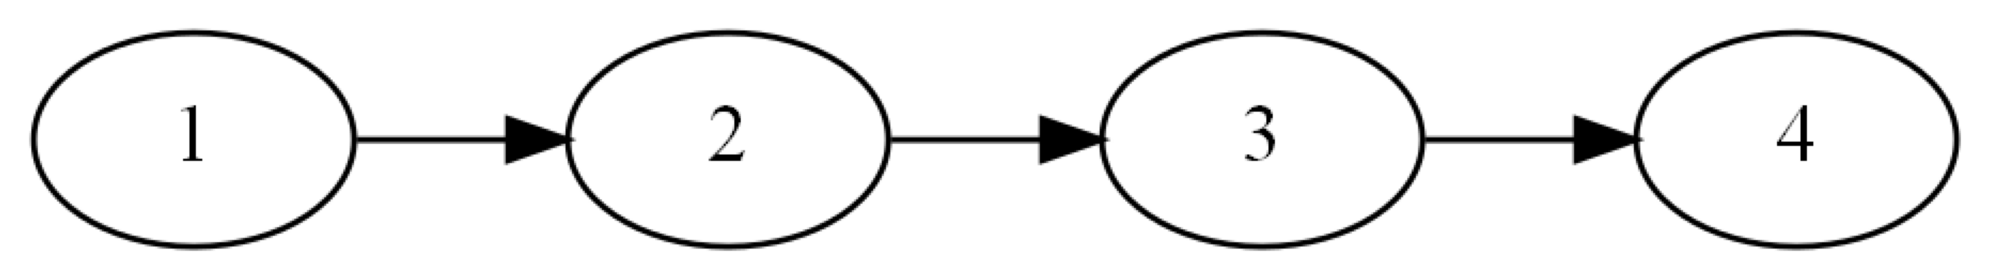

实际聚类顺序: ['2', '4', '1', '3']
传入的连接矩阵内容:
     1    2    3    4
1  0.0  0.0  1.0  0.0
2  0.0  0.0  0.0  0.0
3  0.0  0.0  0.0  1.0
4  0.0  1.0  0.0  0.0
非零连接数: 3
图中的边: [('1', '3'), ('3', '4'), ('4', '2')]
图的节点: ['1', '2', '3', '4']


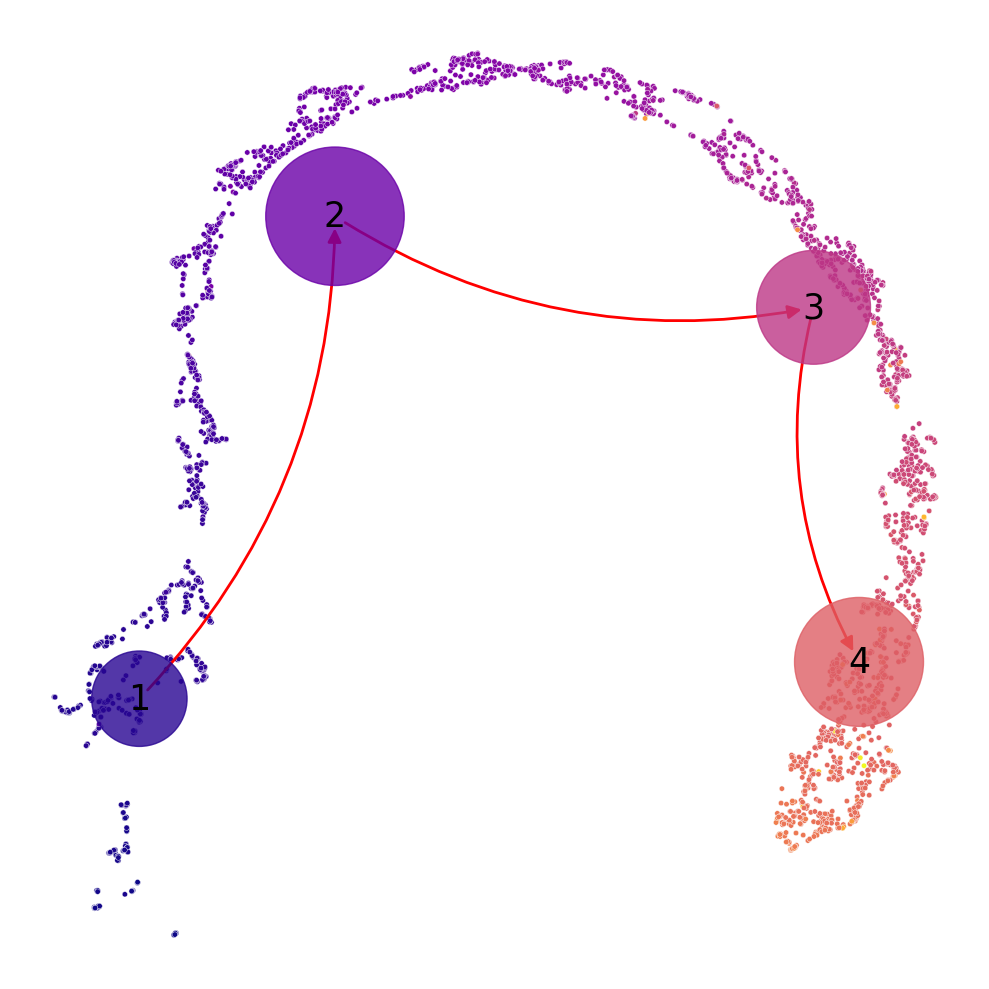

In [12]:
# %%
from models.model_utils import DIPlot

obj = DIPlot(
    adata,
    start_cell_idx=adata.uns['start_id'],
    root=adata.uns['root'],
    group_frac=adata.uns['group_frac'],
    save_path='./result',
    pseudo_key='cascat_pseudotime',
    di_key='cascat_directed_tree_conn',
    predict_key='cascat_clusters',
    emb_key='cascat_embedding'
)

obj.plot_trajectory_tree()
obj.plot_pseudotime()

plot embedding...
plot_embedding failed: list indices must be integers or slices, not str
plot spatial trajectory...
plot_st_embedding failed: list index out of range


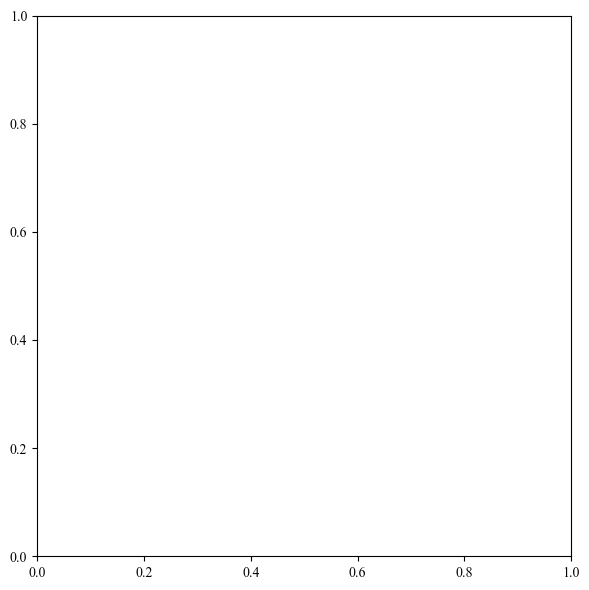

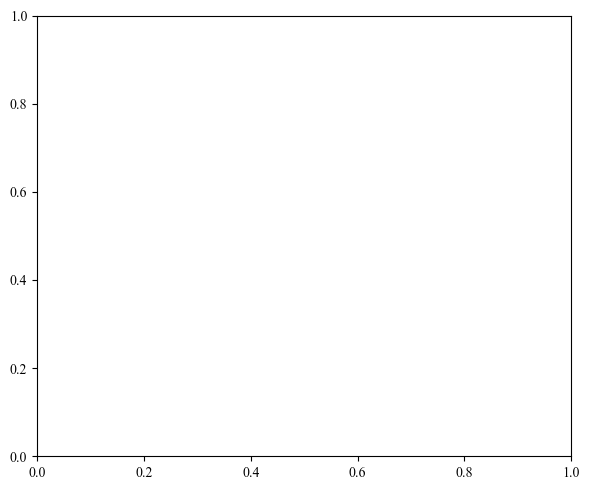

In [12]:
# %%
try:
    print("plot embedding...")
    obj.plot_embedding()
except Exception as e:
    print("plot_embedding failed:", e)

try:
    if 'spatial' in adata.obsm:
        print("plot spatial trajectory...")
        obj.plot_st_embedding(show_trajectory=True)
    else:
        obj.plot_embedding()
except Exception as e:
    print("plot_st_embedding failed:", e)

In [13]:
# %%
if 'gt_pseudotime' in adata.obs.columns and 'cascat_pseudotime' in adata.obs.columns:
    df_pt = adata.obs[['gt_pseudotime', 'cascat_pseudotime']].dropna().copy()

    gt = df_pt['gt_pseudotime'].astype(float).values
    pred = df_pt['cascat_pseudotime'].astype(float).values

    sp1 = spearmanr(gt, pred).correlation
    sp2 = spearmanr(gt, -pred).correlation

    if abs(sp2) > abs(sp1):
        pred = -pred
        adata.obs.loc[df_pt.index, 'cascat_pseudotime'] = pred

    print("Spearman:", spearmanr(gt, pred).correlation)
    print("Kendall :", kendalltau(gt, pred).correlation)
    print("Pearson :", pearsonr(gt, pred)[0])
else:
    print("missing gt_pseudotime or cascat_pseudotime")

Spearman: 0.9571081853847091
Kendall : 0.8186154921246556
Pearson : 0.9534028905026752


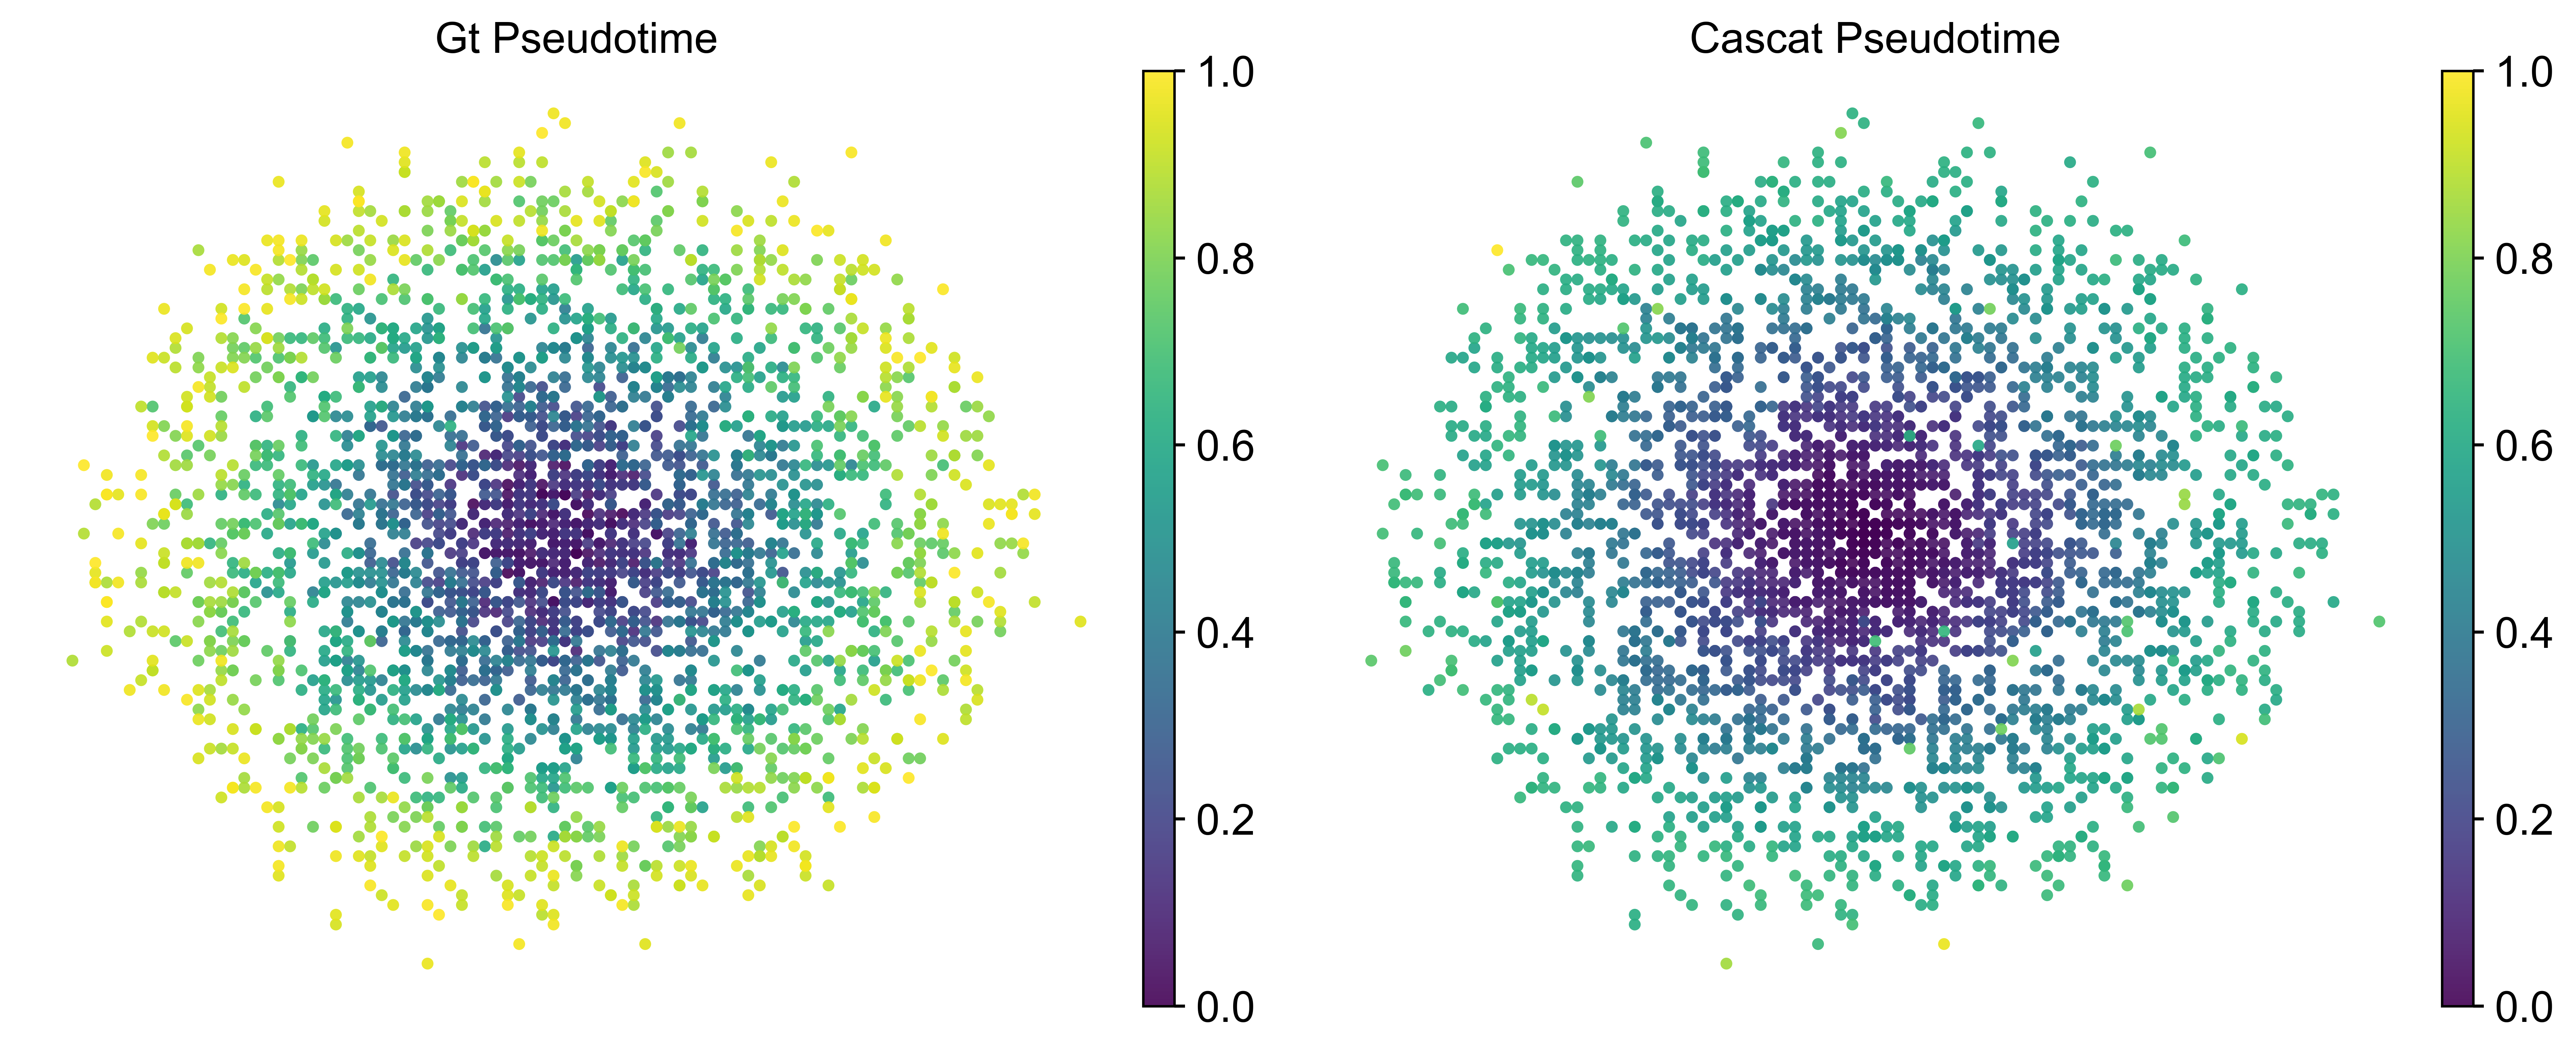

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.titlesize'] = 18

sc.settings.set_figure_params(dpi=300, facecolor='white', frameon=False)

color_list = []
if 'gt_pseudotime' in adata.obs.columns:
    color_list.append('gt_pseudotime')
if 'cascat_pseudotime' in adata.obs.columns:
    color_list.append('cascat_pseudotime')
if not color_list:
    raise KeyError("No pseudotime columns found.")

n_plots = len(color_list)
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
if n_plots == 1:
    axes = [axes]

for ax, col in zip(axes, color_list):
    sc.pl.embedding(
        adata,
        basis='spatial',
        color=col,
        ax=ax,
        show=False,
        title=col.replace('_', ' ').title(),
        color_map='viridis',
        size=60,
        alpha=0.9,
        edgecolor='none',
        legend_loc='right margin',
        colorbar_loc='right',
        add_outline=False,
    )
    ax.get_xaxis().set_visible(True)
    ax.get_yaxis().set_visible(True)
    ax.set_xlabel('X coordinate (pixel/μm)', fontsize=14)
    ax.set_ylabel('Y coordinate (pixel/μm)', fontsize=14)
    ax.locator_params(axis='x', nbins=4)
    ax.locator_params(axis='y', nbins=4)

plt.tight_layout()


plt.show()

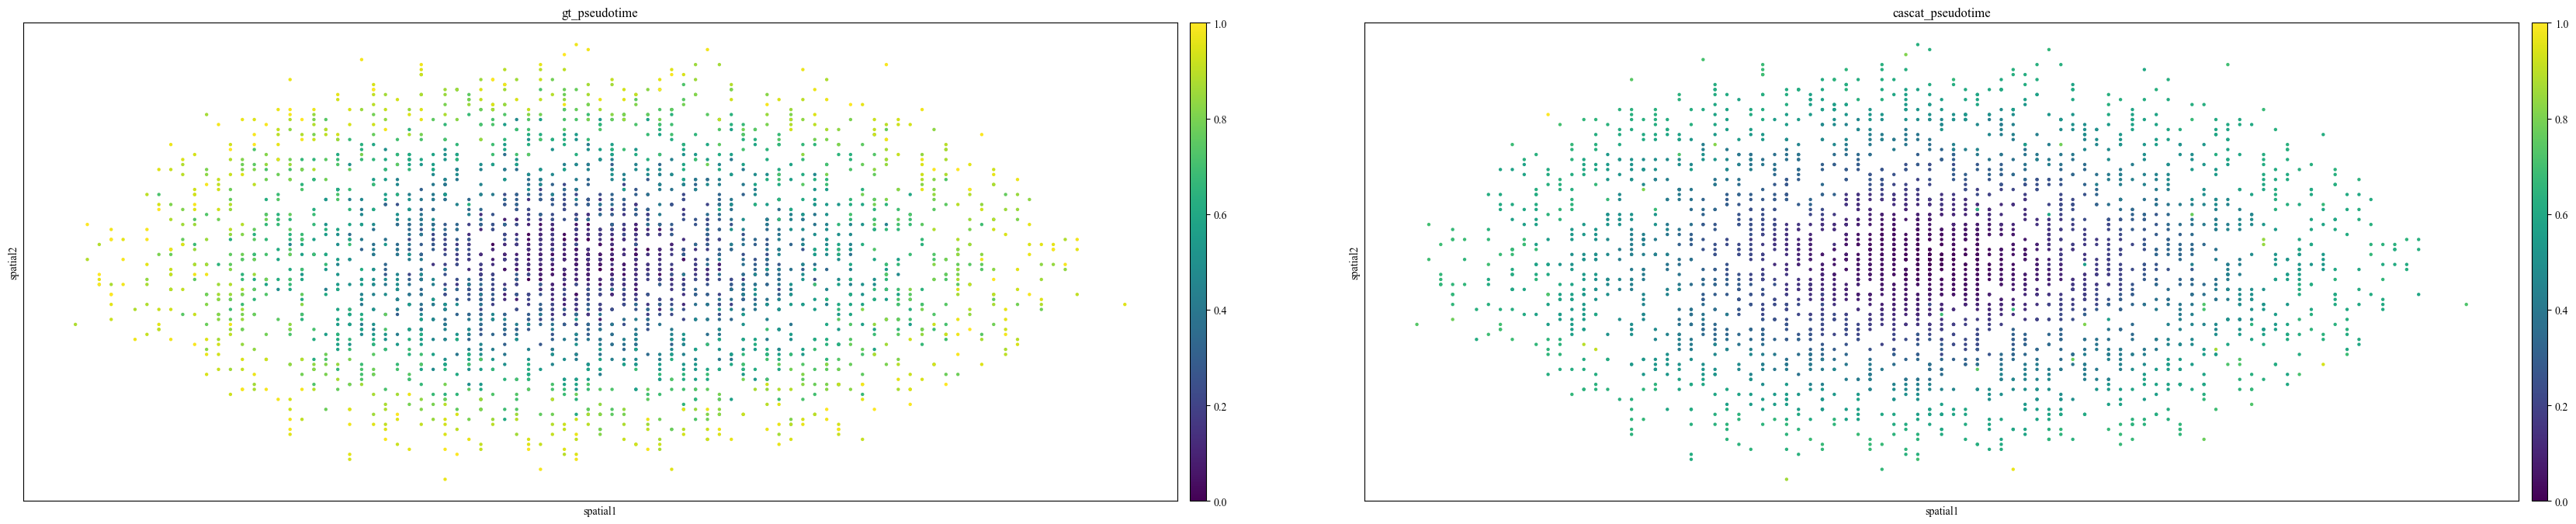

In [14]:
# %%
color_list = []
if 'gt_pseudotime' in adata.obs.columns:
    color_list.append('gt_pseudotime')
if 'cascat_pseudotime' in adata.obs.columns:
    color_list.append('cascat_pseudotime')

sc.pl.embedding(
    adata,
    basis='spatial',
    color=color_list,
    ncols=2
)

In [15]:
# %%
out_dir = os.path.join(".", "result", dataset_name)
os.makedirs(out_dir, exist_ok=True)

adata.write_h5ad(os.path.join(out_dir, f"{dataset_name}_traj.h5ad"))
adata.obs.to_csv(os.path.join(out_dir, f"{dataset_name}_obs_with_pseudotime.csv"))

print("saved to:", out_dir)

IORegistryError: No method registered for writing <class 'numpy.matrix'> into <class 'h5py._hl.group.Group'>

Above error raised while writing key 'gene_freq' of <class 'h5py._hl.group.Group'> to /

In [16]:
# %%
def run_one_dataset(dataset_name, data_dir):
    print("\n" + "="*80)
    print("Running:", dataset_name)

    adata = load_spatrack_simulation(data_dir, dataset_name)

    prefilter_genes(adata, min_cells=3)
    adata, adata_raw = svg(adata, svg_method='gft_top', n_top=1000)

    rad_cutoff = estimate_radius(adata.obsm["spatial"], k=6, scale=1.5)
    obtain_spotnet(adata, knn_method='Radius', rad_cutoff=rad_cutoff)
    gene_freq_mtx, gene_eigvecs_T, gene_eigvals = f2s_gene(adata, gene_signal=1000, c1=0.05)
    obtain_genenet(adata)
    spot_freq_mtx, spot_eigvecs_T, spot_eigvals = f2s_spot(adata, spot_signal=1000, middle=3, c2=0.005)
    obtain_pre_spotnet(adata, adata_raw)

    res, lamda, emb_spot, _, attention = train_spot(
        adata,
        gene_freq_mtx,
        gene_eigvecs_T,
        spot_freq_mtx,
        spot_eigvecs_T,
        alpha=20,
        device=device,
        epoch_max=200
    )

    adata.obsm["emb"] = emb_spot
    sc.pp.neighbors(adata, use_rep='emb')

    cluster_num = adata.obs['cluster'].astype(str).nunique()
    adata = mclust_R(adata, used_obsm='emb', num_cluster=cluster_num)
    adata.obs['mclust'] = adata.obs['mclust'].astype(str)

    adata.obsm['cascat_embedding'] = adata.obsm['emb'].copy()
    adata.obs['cascat_clusters'] = adata.obs['mclust'].astype(str).copy()

    tmp = adata.obs[['cluster', 'gt_pseudotime']].dropna().copy()
    tmp['cluster'] = tmp['cluster'].astype(str)
    root_label = tmp.groupby('cluster')['gt_pseudotime'].median().sort_values().index[0]

    parser = argparse.ArgumentParser()
    parser.add_argument("--root", type=str, default=str(root_label))
    parser.add_argument("--a_k", type=int, default=30)
    parser.add_argument("--ncomp", type=int, default=10)
    parser.add_argument("--threshold", type=float, default=0.3)
    parser.add_argument("--job_dir", type=str, default=fr"./result/trajectory/{dataset_name}")
    parser.add_argument("--seed", type=int, default=2023)
    parser.add_argument("--data_name", type=str, default=dataset_name)
    args_traj = parser.parse_args([])

    exp = InferExperiment(args_traj, adata=adata)

    start_cell_id = adata.obs['gt_pseudotime'].astype(float).idxmin()
    adata.uns['start_id'] = start_cell_id

    exp.infer()

    result = {"dataset": dataset_name}

    if 'cascat_pseudotime' in adata.obs.columns:
        df_pt = adata.obs[['gt_pseudotime', 'cascat_pseudotime']].dropna().copy()
        gt = df_pt['gt_pseudotime'].astype(float).values
        pred = df_pt['cascat_pseudotime'].astype(float).values

        sp1 = spearmanr(gt, pred).correlation
        sp2 = spearmanr(gt, -pred).correlation
        if abs(sp2) > abs(sp1):
            pred = -pred
            adata.obs.loc[df_pt.index, 'cascat_pseudotime'] = pred

        result["spearman"] = spearmanr(gt, pred).correlation
        result["kendall"]  = kendalltau(gt, pred).correlation
        result["pearson"]  = pearsonr(gt, pred)[0]
    else:
        result["spearman"] = np.nan
        result["kendall"]  = np.nan
        result["pearson"]  = np.nan

    out_dir = os.path.join(".", "result", dataset_name)
    os.makedirs(out_dir, exist_ok=True)
    adata.write_h5ad(os.path.join(out_dir, f"{dataset_name}_traj.h5ad"))
    adata.obs.to_csv(os.path.join(out_dir, f"{dataset_name}_obs_with_pseudotime.csv"))

    return result

In [ ]:
# %%
dataset_list = [f"discrete_rep{i:02d}" for i in range(1, 21)]

all_results = []
for ds in dataset_list:
    try:
        res = run_one_dataset(ds, DATA_DIR)
        all_results.append(res)
        print(res)
    except Exception as e:
        print("FAILED:", ds, e)

res_df = pd.DataFrame(all_results)
res_df


Running: discrete_rep01
gene edges 1002 spots 3000
spot*signal train


100%|██████████| 200/200 [00:18<00:00, 10.89it/s]


fitting ...
  |======================================================================| 100%
using keys are cascat_clusters, cascat_embedding, cascat_connectivities, cascat_pseudotime, cascat_di_matrix
group_frac:        4      2      1      3
3   76.0  362.0  286.0   26.0
2    8.0   84.0  383.0  275.0
1    0.0    9.0  115.0  626.0
4  182.0  519.0   49.0    0.0
No start cell id, use truth label in cluster to find start cell
Root is 3, Start cell idx is 2283
Finish load Infer params
Finish initialize tree params
树节点: ['4', '2', '1', '3']
=== 基于DI矩阵构建树结构 ===
计算全局DI矩阵: ./result/trajectory/discrete_rep01/trial2023/global_DI_matrix.csv
DI计算进度: 1/4
全局DI矩阵已保存
完全图构建完成: 4 节点, 6 边
最小生成树构建完成: 3 边
有向树构建完成: 3 边
=== 树结构二值化 ===
树结构二值化完成
树构建完成: 4 节点, 3 边
开始基于DI的树构建
树节点: ['4', '2', '1', '3']
=== 基于DI矩阵构建树结构 ===
计算全局DI矩阵: ./result/trajectory/discrete_rep01/trial2023/global_DI_matrix.csv
加载已存在的DI矩阵
完全图构建完成: 4 节点, 6 边
最小生成树构建完成: 3 边
有向树构建完成: 3 边
=== 树结构二值化 ===
树结构二值化完成
树构建完成: 4 节点, 3 边
✅ 有向树邻接矩阵生成完成，已存入ada

100%|██████████| 200/200 [00:19<00:00, 10.06it/s]


fitting ...
  |======================================================================| 100%
using keys are cascat_clusters, cascat_embedding, cascat_connectivities, cascat_pseudotime, cascat_di_matrix
group_frac:        3      2      1      4
4    5.0  166.0  578.0    1.0
2  301.0  159.0   77.0  213.0
1  125.0   20.0    6.0  599.0
3  128.0  323.0  289.0   10.0
No start cell id, use truth label in cluster to find start cell
Root is 4, Start cell idx is 883
Finish load Infer params
Finish initialize tree params
树节点: ['4', '2', '1', '3']
=== 基于DI矩阵构建树结构 ===
计算全局DI矩阵: ./result/trajectory/discrete_rep02/trial2023/global_DI_matrix.csv
DI计算进度: 1/4
全局DI矩阵已保存
完全图构建完成: 4 节点, 6 边
最小生成树构建完成: 3 边
有向树构建完成: 3 边
=== 树结构二值化 ===
树结构二值化完成
树构建完成: 4 节点, 3 边
开始基于DI的树构建
树节点: ['4', '2', '1', '3']
=== 基于DI矩阵构建树结构 ===
计算全局DI矩阵: ./result/trajectory/discrete_rep02/trial2023/global_DI_matrix.csv
加载已存在的DI矩阵
完全图构建完成: 4 节点, 6 边
最小生成树构建完成: 3 边
有向树构建完成: 3 边
=== 树结构二值化 ===
树结构二值化完成
树构建完成: 4 节点, 3 边
✅ 有向树邻接矩阵生成完成，已存入adat